q1

In [5]:
import numpy as np
A=[225,215,250,225,205]
B=[220,225,250,250,210]
r=4.33/100
def PV(A,r):
    i=1
    S=0
    for S0 in A:
      S=S+S0*np.exp(-r*i)
      i=i+1
    return S
if PV(A,r)>PV(B,r):
   print('Investment A is proferable',PV(A,r))
else:
    print('Investment B is proferable',PV(B,r))

      

Investment B is proferable 1015.9201516869825


2q1

In [14]:

def bond_price(c,r):
    C=0
    i=0
    for c0 in c:
        C=C+c0*np.exp(-r*(i+1))
        i=i+1
    return C 

c=[8,8,8,8,108]
r=.11
print(bond_price(c,r))
##bond duration

def bond_duration(c,r):
    C=0
    i=0
    for c0 in c:
        C=C+c0*np.exp(-r*(i+1))*(i+1)/bond_price(c,r)
        i=i+1
    return C 
p=bond_price(c,r)
t=bond_duration(c,r)
print(t)
#price change
del_r=-0.2/100
del_p=-p*t*del_r
new_bond_price=p+del_p
print(new_bond_price)
#
r=r+del_r
p=bond_price(c,r)
print(p)








86.80108422328516
4.255974563427865
87.53993063634968
87.54339139534211


q3

In [16]:
A=[460,235,640,370,330,250]
def PV(c,r):
    C=0
    i=1
    for c0 in c:
        C=C+c0/(1+r)**(i)
        i=i+1
    return C 
r=0.045
r=(1+(r/4))**4-1
print(PV(A,r))


1978.6860139433957


q4

In [21]:
s0=40
r=0.1
T=1
k=s0*np.exp(r*T)
#initial value
forward_contract=s0-k*np.exp(-r*T)
print("intial forward contract price",forward_contract)

#1/2yr later (b)
t=1/2
s=45
forward_contract=s-k*np.exp(-r*(T-t))
k=s0*np.exp(r*T)
print("forward Price",k)
print("6 month later forward contract price",forward_contract)




intial forward contract price 0.0
forward Price 44.20683672302591
6 month later forward contract price 2.9491561449590336


q5

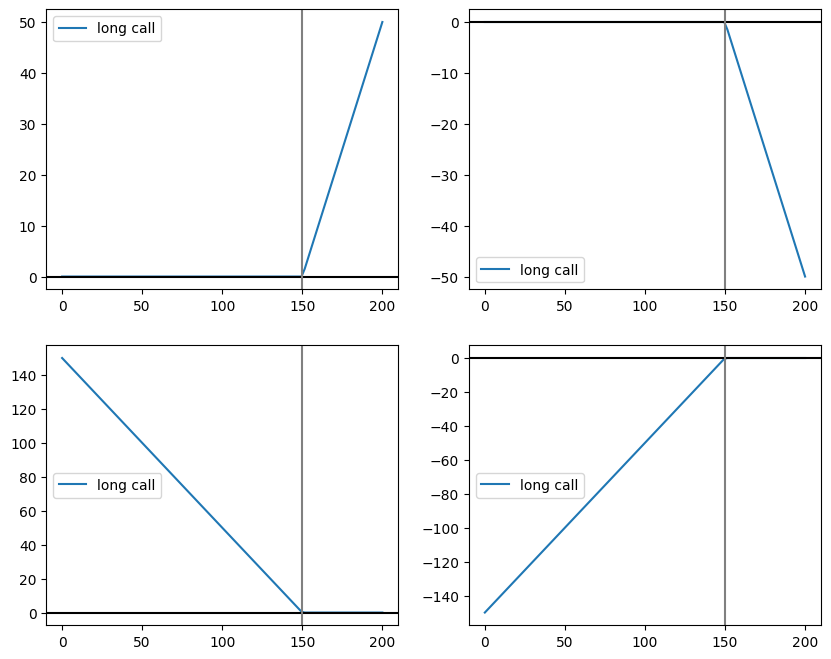

In [31]:
import numpy as np
import matplotlib.pyplot as plt
k=150
p=5
s=np.linspace(0,200,100)
long_call=np.maximum(s-k,0)
short_call=-np.maximum(s-k,0)
long_put=np.maximum(k-s,0)
short_put=-np.maximum(k-s,0)
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.plot(s,long_call,label='long call')
plt.axhline(0,color='black')
plt.axvline(k,color='grey')
plt.legend()

plt.subplot(2,2,2)
plt.plot(s,short_call,label='long call')
plt.axhline(0,color='black')
plt.axvline(k,color='grey')
plt.legend()

plt.subplot(2,2,3)
plt.plot(s,long_put,label='long call')
plt.axhline(0,color='black')
plt.axvline(k,color='grey')
plt.legend()

plt.subplot(2,2,4)
plt.plot(s,short_put,label='long call')
plt.axhline(0,color='black')
plt.axvline(k,color='grey')
plt.legend()
plt.show()



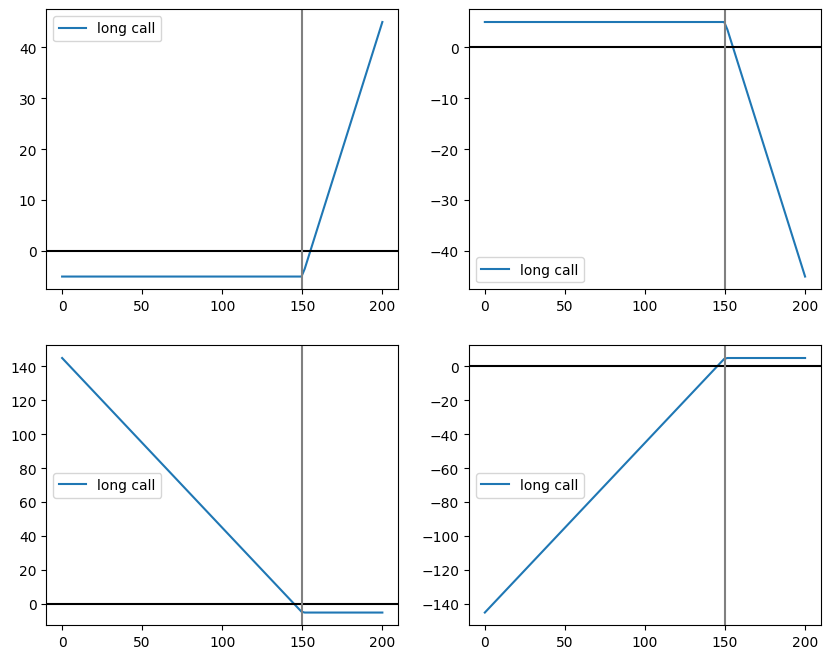

In [32]:
import numpy as np
import matplotlib.pyplot as plt
k=150
p=5
s=np.linspace(0,200,100)
long_call=np.maximum(s-k,0)-p
short_call=-np.maximum(s-k,0)+p
long_put=np.maximum(k-s,0)-p
short_put=-np.maximum(k-s,0)+p
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.plot(s,long_call,label='long call')
plt.axhline(0,color='black')
plt.axvline(k,color='grey')
plt.legend()

plt.subplot(2,2,2)
plt.plot(s,short_call,label='long call')
plt.axhline(0,color='black')
plt.axvline(k,color='grey')
plt.legend()

plt.subplot(2,2,3)
plt.plot(s,long_put,label='long call')
plt.axhline(0,color='black')
plt.axvline(k,color='grey')
plt.legend()

plt.subplot(2,2,4)
plt.plot(s,short_put,label='long call')
plt.axhline(0,color='black')
plt.axvline(k,color='grey')
plt.legend()
plt.show()



q6

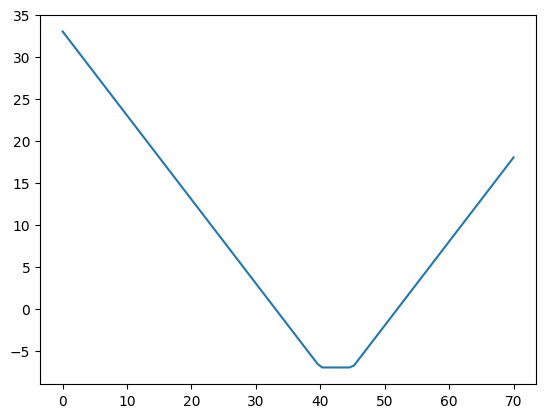

In [35]:
'''
long call +long put=strangle
'''
s=np.linspace(0,70,100)
long_call=np.maximum(s-45,0)-3
long_put=np.maximum(40-s,0)-4
strangle=long_call+long_put
plt.plot(s,strangle)
plt.show()


q7

In [37]:
s=19
k=20
c=1
r=3/100
T=1/3
#put call pairity p+s=c+kexp(-rT)
p=c+k*np.exp(-r*T)-s
print(p)


1.800996674983363


q8

In [43]:
from scipy.stats import norm
def bsl_call(r,s,k,T,sigma):
    d1=(np.log(s/k)+(r+sigma**2/2)*T)/(sigma*np.sqrt(T))
    d2=d1-sigma*np.sqrt(T)
    return s*norm.cdf(d1)-k*np.exp(-r*T)*norm.cdf(d2)
def bsl_put(r,s,k,T,sigma):
    d1=(np.log(s/k)+(r+sigma**2/2)*T)/(sigma*np.sqrt(T))
    d2=d1-sigma*np.sqrt(T)
    return k*np.exp(-r*T)*norm.cdf(-d2)-s*norm.cdf(-d1)
s=32
sigma=0.3
r=5/100
k1=25
k2=30
T=1/2
c1=bsl_call(r,s,k1,T,sigma)
c2=bsl_call(r,s,k2,T,sigma)
p1=bsl_put(r,s,k1,T,sigma)
p2=bsl_put(r,s,k2,T,sigma)
print("Bull speard",c1-c2)
print("bear speard",p2-p1)
k1=25
k2=30
k3=35
T=1
c1=bsl_call(r,s,k1,T,sigma)
c2=bsl_call(r,s,k2,T,sigma)
c3=bsl_call(r,s,k3,T,sigma)
print("Butterfly",c1-2*c2+c3)
p1=bsl_put(r,s,k1,T,sigma)
p2=bsl_put(r,s,k2,T,sigma)
p3=bsl_put(r,s,k3,T,sigma)
print("put butterfly",p1-2*p2+p3)
k1=25
k2=30
T=1/2
p1=bsl_put(r,s,k2,T,sigma)
c1=bsl_call(r,s,k2,T,sigma)
print("straddle",c1+p1)
k1=25
k2=35
p1=bsl_put(r,s,k1,T,sigma)
c1=bsl_call(r,s,k2,T,sigma)
print("strangle",c1+p1)



Bull speard 3.7129815835540576
bear speard 1.16356797658761
Butterfly 1.0009096879706725
put butterfly 1.0009096879706725
straddle 5.62672130157711
strangle 2.1328040823930485


q9

In [45]:
s=30
k=29
r=5/100
sigma=25/100
T=4/12
p1=bsl_put(r,s,k,T,sigma)
c1=bsl_call(r,s,k,T,sigma)
print("European call",c1)
print("European put",p1)
if p1+s-c1-k*np.exp(-r*T)==0:
    print('Put-call pairity')


European call 2.5251469666999995
European put 1.045819127526908
Put-call pairity


q10

In [ ]:
s0=60
k=60
sigma=0.3
r=0.08
t=1/4
u=np.exp(sigma*np.sqrt(t))
d=1/u
p=(1-d)/(u-d)
cuu=np.maximum(s0*u**2-k,0)
cdd=np.maximum(s0*u*d-k,0)
cud=np.maximum(s0*u*d-k,0)

cu=np.exp(-r*t)*(p*cuu+(1-p)*cud)
cd=np.exp(-r*t)*(p*cud+(1-p)*cdd)

c=np.exp(-r*t)*(p*cu+(1-p)*cd)
print(c)
#american option
cu=np.maximum(cu,np.maximum(s0*u-k,0))
cd=np.maximum(cd,np.maximum(s0*d-k,0))
c=np.exp(-r*t)*(p*cu+(1-p)*cd)
print(c)


4.31546401384552
4.402642169762441


q11

In [15]:
k=480
s=484
q=0.03
sigma=0.25
N=4
t=2/12
dt=t/4
u=np.exp(sigma*np.sqrt(dt))
d=1/u
p=(np.exp(dt*(r-q))-d)/(u-d)
df=np.exp(-r*dt)
stock_mat=np.zeros((N+1,N+1))
for i in range(N+1):
    for j in range(i+1):
        stock_mat[i,j]=s*u**(i-j)*d**(j)
print(stock_mat)     
option_mat=np.zeros((N+1,N+1))

for j in range(N+1):
    option_mat[N,j]=np.maximum(-stock_mat[N,j]+k,0)


for i in range(N-1,-1,-1):
    for j in range(i+1):
        continuation=df*(p*option_mat[i+1,j]+(1-p)*option_mat[i+1,j+1])
        excercise=np.maximum(k-stock_mat[i,j],0)
        option_mat[i,j]=np.maximum(continuation,excercise)
print(option_mat[0,0])      



[[484.           0.           0.           0.           0.        ]
 [509.34008814 459.92060208   0.           0.           0.        ]
 [536.00687063 484.         437.039174     0.           0.        ]
 [564.0698073  509.34008814 459.92060208 415.29611578   0.        ]
 [593.60199456 536.00687063 484.         437.039174   394.63479259]]
14.933233649496977


In [16]:
import numpy as np
k=480
s=484
T=1/6
dt=T/4
N=4
r=10/100
q=0.03
sigma=25/100
u=np.exp(sigma*np.sqrt(dt))
d=1/u
p=(np.exp((r-q)*dt)-d)/(u-d)

stock_mat=np.zeros((N+1,N+1))

for i in range(N+1):
    for j in range(i+1):
        stock_mat[i,j]=s*u**(i-j)*d**j
print(stock_mat)
option_price=np.zeros((N+1,N+1))
for i in range(N+1):
    option_price[N,i]=np.maximum(-stock_mat[N,i]+k,0)
df=np.exp(-r*dt)
for i in range(N-1,-1,-1):
    for j in range(i+1):
     continuation=df*(p*option_price[i+1,j]+(1-p)*option_price[i+1,j+1])
     excercise=np.maximum(k-stock_mat[i,j],0)
     option_price[i,j]=np.maximum(continuation,excercise)
print(option_price)

print(option_price[0,0])

[[484.           0.           0.           0.           0.        ]
 [509.34008814 459.92060208   0.           0.           0.        ]
 [536.00687063 484.         437.039174     0.           0.        ]
 [564.0698073  509.34008814 459.92060208 415.29611578   0.        ]
 [593.60199456 536.00687063 484.         437.039174   394.63479259]]
[[14.93323365  0.          0.          0.          0.        ]
 [ 4.81481062 25.84302528  0.          0.          0.        ]
 [ 0.          9.98643196 42.960826    0.          0.        ]
 [ 0.          0.         20.7129275  64.70388422  0.        ]
 [ 0.          0.          0.         42.960826   85.36520741]]
14.933233649496977
